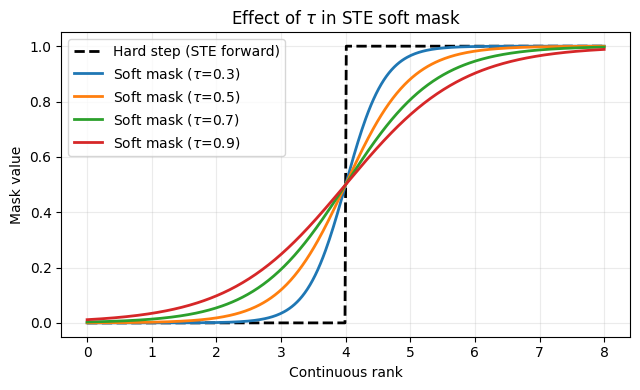

Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/ste_tau_comparison.png


In [5]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Same soft part used in your STE mask: sigmoid((r_cont - k) / tau)
def soft_mask_for_k(r_cont: torch.Tensor, k: int, tau: float):
    tau = max(float(tau), 1e-6)
    k_t = torch.tensor(float(k), dtype=r_cont.dtype, device=r_cont.device)
    return torch.sigmoid((r_cont - k_t) / tau)

# Continuous rank axis
r = torch.linspace(0, 8, 400)
k = 4  # one rank boundary to visualize
taus = [0.3, 0.5, 0.7, 0.9]

plt.figure(figsize=(6.5, 4.0))

# Hard step used in STE forward pass
hard = (r >= k).float()
plt.plot(r.numpy(), hard.numpy(), "k--", linewidth=2, label="Hard step (STE forward)")

# Soft curves used for gradients in STE backward pass
for tau in taus:
    y = soft_mask_for_k(r, k=k, tau=tau)
    plt.plot(r.numpy(), y.numpy(), linewidth=2, label=fr"Soft mask ($\tau$={tau})")

plt.title(r"Effect of $\tau$ in STE soft mask")
plt.xlabel("Continuous rank")
plt.ylabel("Mask value")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

# Save high-DPI figure
out_dir = Path("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "ste_tau_comparison.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")

plt.show()
print(f"Saved figure to: {out_path}")